<a href="https://colab.research.google.com/github/Vineet-salimath/NLP_Preprocessing_Engine/blob/main/SENTIMENTAL_ANALYSIS_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1 DATA UNDERSTANDING

In [35]:
!pip install kagglehub pandas numpy scikit-learn nltk gensim matplotlib seaborn

LOAD THE DATASET

In [33]:
import kagglehub, os
path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

files = os.listdir(path)
print("Files found:", files)

csv_path = os.path.join(path, "IMDB Dataset.csv")
print("Full CSV path:", csv_path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Files found: ['IMDB Dataset.csv']
Full CSV path: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
✓ Dataset ready!


FEW SAMPLES

In [22]:
import pandas as pd

df = pd.read_csv(csv_path)

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Shape of dataset:", df.shape)   print("\nFirst 10 rows:")
display(df.head(10))
print("✓ Data loaded and labels encoded!")

Shape of dataset: (50000, 2)

First 10 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
5,"Probably my all-time favorite movie, a story o...",1
6,I sure would like to see a resurrection of a u...,1
7,"This show was an amazing, fresh & innovative i...",0
8,Encouraged by the positive comments about this...,0
9,If you like original gut wrenching laughter yo...,1


✓ Data loaded and labels encoded!


CLASS DISTRIBUTION AND THE SAMPLE REVIEWS

In [23]:
print("=== Dataset Info ===")
print("Total rows:", len(df))
print("\nClass distribution:")
print(df['sentiment'].value_counts())
print("\nSample reviews:")
display(df.sample(3)[['review', 'sentiment']])

df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(f"\nAverage words per review: {df['word_count'].mean():.0f}")
print(f"Min: {df['word_count'].min()}, Max: {df['word_count'].max()}")

=== Dataset Info ===
Total rows: 50000

Class distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Sample reviews:


,review,sentiment
12682,**SPOILERS** Simple movie about simple people ...,1
48548,Hardware Wars rips off EVERYTHING in Star Wars...,0
17881,I viewed the movie for a second time on Septem...,1



Average words per review: 231
Min: 4, Max: 2470


TASK 2 NLP PREPROCESSING

In [36]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stop_words.discard('not')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    cleaned = [lemmatizer.lemmatize(w)
               for w in words
               if w not in stop_words]
    return " ".join(cleaned)
df['clean_text'] = df['review'].apply(clean_text)
print("Done! Sample cleaned review:")
print(df['clean_text'].iloc[0][:200])

Done! Sample cleaned review:
one reviewer mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid s


In [38]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

print(len(X_train_text))
print(len(X_test_text))

40000
10000


TASK 3 FEATURE ENGINEERING

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train_text)
X_test_bow  = bow_vec.transform(X_test_text)

print(X_train_bow.shape)
print(X_test_bow.shape)

(40000, 5000)
(10000, 5000)


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vec.transform(X_test_text)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(40000, 5000)
(10000, 5000)


TASK 4 MODEL BUILIDING

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                               recall_score, f1_score)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes":         MultinomialNB(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=20)
}


def evaluate_all(X_train, X_test, vec_name, use_gaussian=False):
    for name, model in models.items():
        m = GaussianNB() if (name == "Naive Bayes" and use_gaussian) else model
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        results.append({
            "Model":      name,
            "Vectorizer": vec_name,
            "Accuracy":   round(accuracy_score(y_test, y_pred),  4),
            "Precision":  round(precision_score(y_test, y_pred, average='weighted'), 4),
            "Recall":     round(recall_score(y_test, y_pred, average='weighted'),    4),
            "F1 Score":   round(f1_score(y_test, y_pred, average='weighted'),      4)
        })
        print(f"  ✓ {name} ({vec_name}): F1 = {results[-1]['F1 Score']}")
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df = results_df.reset_index(drop=True)
print("\nFINAL RESULTS")
display(results_df)

results_df.to_csv('/content/model_results.csv', index=False)


FINAL RESULTS


,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,TF-IDF,0.8876,0.8878,0.8876,0.8876
1,Logistic Regression,Bag of Words,0.8726,0.8726,0.8726,0.8726
2,Logistic Regression,Word2Vec,0.8563,0.8564,0.8563,0.8563
3,Naive Bayes,TF-IDF,0.8518,0.8518,0.8518,0.8518
4,Naive Bayes,Bag of Words,0.8481,0.8481,0.8481,0.8481
5,Naive Bayes,Word2Vec,0.7646,0.7646,0.7646,0.7646
6,Decision Tree,Bag of Words,0.7414,0.7457,0.7414,0.7401
7,Decision Tree,Word2Vec,0.7351,0.7351,0.7351,0.7351
8,Decision Tree,TF-IDF,0.7357,0.7413,0.7357,0.7339


TASK 5 MODEL EVALUATION

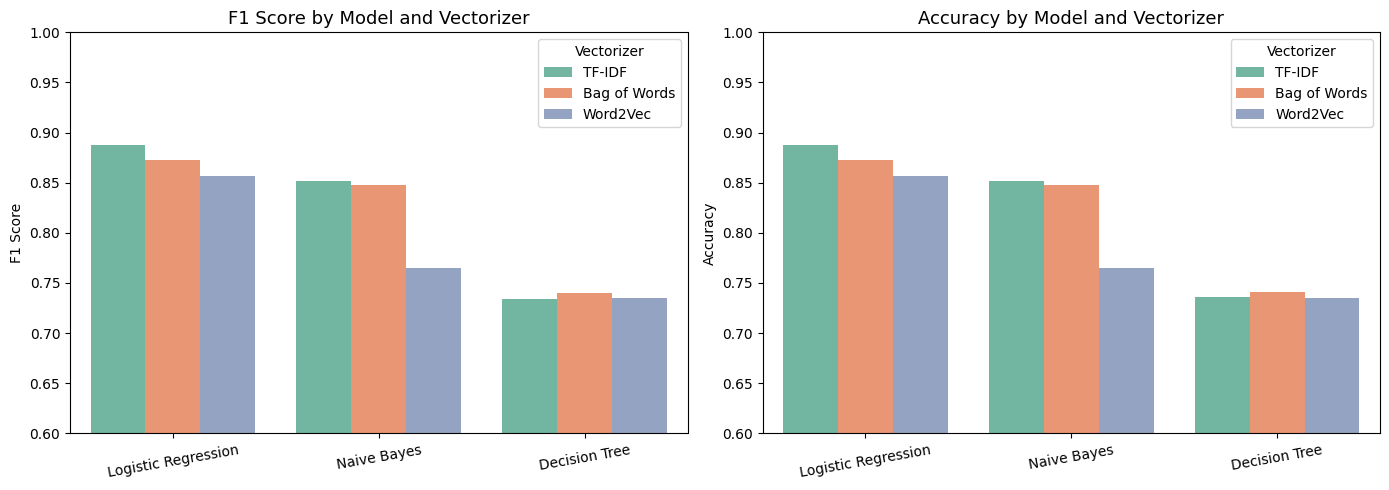

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=results_df,
    x='Model', y='F1 Score', hue='Vectorizer',
    ax=axes[0], palette='Set2'
)
axes[0].set_title('F1 Score by Model and Vectorizer', fontsize=13)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=10)
sns.barplot(
    data=results_df,
    x='Model', y='Accuracy', hue='Vectorizer',
    ax=axes[1], palette='Set2'
)
axes[1].set_title('Accuracy by Model and Vectorizer', fontsize=13)
axes[1].set_ylim(0.6, 1.0)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
TASK 6 COMPARSION AND INSIGHTS

In [45]:

best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)

def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vector  = tfidf_vec.transform([cleaned])
    pred    = best_model.predict(vector)[0]
    prob    = best_model.predict_proba(vector)[0]
    label   = "POSITIVE " if pred == 1 else "NEGATIVE "
    conf    = max(prob) * 100
    print(f'Review: "{review_text[:60]}..."')
    print(f'Prediction: {label}  (SCORE: {conf:.1f}%)\n')
test_reviews = [
    "This movie was absolutely brilliant. I loved every second of it!",
    "Terrible film. Waste of time and money. Not worth watching at all.",
    "Not bad, but not great either. Pretty average overall.",
    "The acting was not good and the story made no sense.",
]

for review in test_reviews:
    predict_sentiment(review)

Review: "This movie was absolutely brilliant. I loved every second of..."
Prediction: POSITIVE   (SCORE: 97.5%)

Review: "Terrible film. Waste of time and money. Not worth watching a..."
Prediction: NEGATIVE   (SCORE: 99.9%)

Review: "Not bad, but not great either. Pretty average overall...."
Prediction: NEGATIVE   (SCORE: 80.6%)

Review: "The acting was not good and the story made no sense...."
Prediction: NEGATIVE   (SCORE: 70.6%)



PREPROCESSING

In this project, preprocessing turned out to be very important for improving the model performance. I cleaned the text by removing HTML tags, punctuation, and URLs, which helped reduce noise in the dataset.

One important decision I made was not removing the word “not” from stopwords. Normally, stopwords are removed, but in sentiment analysis “not” changes the meaning completely. For example, “not good” is negative, while “good” is positive. So keeping “not” helped the model understand sentiment better.

I also used lemmatization, which converts words into their base form (like “running” → “run”). This helped reduce duplicate features and made the model more consistent.

 Overall, proper cleaning + keeping important words + lemmatization gave better results.










VECTORIZATION TECHNIQUES

I used three different methods to convert text into numbers:

Bag of Words (BoW):
This method just counts how many times each word appears. It is simple and fast, but it treats all words equally and does not consider importance.

TF-IDF:
This performed the best among all. It gives less importance to very common words like “movie” and more importance to meaningful words like “excellent” or “bad”. Because of this, it gave higher accuracy and F1-score.

Word2Vec (Bonus):
This method is more advanced because it understands the meaning of words. However, since I averaged all word vectors in a review, some important sentiment information got diluted. That’s why its performance was slightly lower than TF-IDF.

 So, TF-IDF worked best overall in this task.







Logistic Regression:
This gave the best results. It handled the high number of features very well and gave the highest F1-score. It also did not overfit much.

Naive Bayes:
This was fast and gave decent results. However, it assumes all features are independent, which is not true for language, so performance was slightly lower.

Decision Tree:
This performed the worst. It tends to overfit when there are too many features (like in text data), so it did not generalize well on test data.

 So, Logistic Regression was the best model.



TRADE OFFS

BoW is simple but less accurate
TF-IDF is more accurate but still ignores word order
Word2Vec understands meaning but needs better models to perform fully
Logistic Regression is accurate and stable
Naive Bayes is fast but less realistic
Decision Tree is easy to understand but overfits easily


FINAL CONCLUSION

From all experiments, I found that:

Best preprocessing → cleaning + lemmatization + keeping “not”
Best vectorization → TF-IDF
Best model → Logistic Regression

The best combination overall is:
TF-IDF + Logistic Regression